# Análise de dados de Sistema de Monitoramento

O presente trabalho tem como objetivo analisar os dados das avaliações Formativa 3 aplicadas no programa PBA Sergipe para entender a eficácia pedagógica do programa através de seus instrumentos. No entanto, o presente relatório busca analisar somente os dados de 30 turmas provenientes de aditivo de contrato. Segue lista de código de turmas a serem analisadas aqui:

TURMA-P0000009-0002; 
TURMA-P0000135-0001; 
TURMA-P0000004-0002; 
TURMA-P0000026-0002; 
TURMA-28000013-0007; 
TURMA-28000013-0008; 
TURMA-28009398-0018; 
TURMA-28018389-0012; 
TURMA-P0000136-0001; 
TURMA-28018575-0017; 
TURMA-28023315-0010; 
TURMA-28021177-0005; 
TURMA-28029577-0010; 
TURMA-28003047-0001; 
TURMA-28020553-0001; 
TURMA-28014170-0001; 
TURMA-28014170-0002; 
TURMA-28003624-0001; 
TURMA-28003365-0005; 
TURMA-28003411-0001; 
TURMA-28003411-0002; 
TURMA-28009983-0008; 
TURMA-28009983-0009; 
TURMA-28007409-0001; 
TURMA-28029372-0003; 
TURMA-28029372-0004; 
TURMA-28007360-0003; 
TURMA-28030451-0001; 
TURMA-28003500-0007; 
TURMA-28003500-0008.


## Importando bibliotecas e dados

In [1]:
# Importando bibliotecas
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, wilcoxon

# Importando arquivo
df_cadastro = pd.read_excel(
    'Data_files/public_data/xls_pedagogico_19112025.xlsx')
df_turmas = pd.read_excel(
    'Data_files/public_data/turmas_19112025.xlsx')
df_registros = pd.read_excel(
    'Data_files/public_data/xls_detalhado_19112025.xlsx')
df_relatorios_diagnostica = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_diagnostica_19112025.xlsx')
df_relatorios_formativa1 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa1_19112025.xlsx')
df_relatorios_formativa2 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa2_19112025.xlsx')
df_relatorios_formativa3 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa3_19112025.xlsx')
df_relatorios_formativa4 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa4_19112025.xlsx')
df_relatorios_somativa = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_somativa_19112025.xlsx')

print('df_cadastro:')
print(df_cadastro.info())
#print(df_cadastro.head())

print('df_turmas:')
print(df_turmas.info())
#print(df_turmas.head())

print('df_registros:')
print(df_registros.info())
#print(df_registros.head())

print('df_relatorios_diagnostica:')
print(df_relatorios_diagnostica.info())
#print(df_relatorios_diagnostica.head())

print('df_relatorios_formativa1:')
print(df_relatorios_formativa1.info())
#print(df_relatorios_formativa1.head())

print('df_relatorios_formativa2:')
print(df_relatorios_formativa2.info())
#print(df_relatorios_formativa2.head())

print('df_relatorios_formativa3:')
print(df_relatorios_formativa3.info())
#print(df_relatorios_formativa3.head())

print('df_relatorios_formativa4:')
print(df_relatorios_formativa4.info())
#print(df_relatorios_formativa4.head())

print('df_relatorios_somativa:')
print(df_relatorios_somativa.info())
#print(df_relatorios_somativa.head())


df_cadastro:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4588 entries, 0 to 4587
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   CPF                        4588 non-null   object
 1   Nome                       4588 non-null   object
 2   Turma                      4588 non-null   object
 3   Data de início             4588 non-null   object
 4   Alfabetizador              4588 non-null   object
 5   Coordenador                4588 non-null   object
 6   Qtde presença              4588 non-null   int64 
 7   Qtde ausência              4588 non-null   int64 
 8   Atividade - Entrada        4582 non-null   object
 9   Atividade - Formativa 1    4582 non-null   object
 10  Atividade - Formativa 2    4588 non-null   object
 11  Atividade - Formativa 3    4585 non-null   object
 12  Atividade - Formativa 4    4506 non-null   object
 13  Atividade - Saída          3616 non-null   object


## Tratando dos dados
Se faz necessário a transformação dos dados para que seja mais fácil sua análise. De acordo com a observação dos dados apresentados, as seguintes transformações serão necessárias:
Em df_registros:
- Transformar nomes de cada coluna para o padrão snake_case;
- Extrair somente os níveis da coluna "Nível";
- Deixar os níveis de maneira categórica corretamente para melhor análise na coluna "Nível".

Em df_relatorios
- Transformar nomes de cada coluna para o padrão snake_case;
- As colunas que contém perguntas serão reduzidas somente a palavra "pergunta" seguida do seu número, exemplo: pergunta_1
- As categorias de resposta serão resumidas em no máximo 3 palavras para facilitar a interpretação - um dicionário será criado aqui.

Em df_cadastro, df_turmas, df_relatorios_(diagnostica / formativa1, 2 e 3):
- Todas as colunas que contem datas deverão ser tranformados para o tipo datetime.

In [2]:
# Transformando nomes de colunas para padrão snake_case
# Função para converter para snake_case
def to_snake_case(column_name):
    return (
        column_name
        .lower()  # Converte tudo para minúsculo
        .replace(' ', '_')  # Substitui espaços por underscore
        .replace('é', 'e')  # Remove acentos
        .replace('ã', 'a')
        .replace('ç', 'c')
        .replace('í', 'i')
        .replace('ó', 'o')
        .replace('ú', 'u')
        .replace('á', 'a')
    )

# Função para extrair o número de perguntas e renomear
def renomear_perguntas(nome_coluna):
    match = re.match(r'^(\d+)\._', nome_coluna)  # Procura o padrão "X._" no início
    if match:
        numero = match.group(1)
        return f'pergunta_{numero}'
    return nome_coluna  # Mantém o nome original se não for uma pergunta numerada

# Aplica a função to_snake_case aos nomes das colunas
df_cadastro.columns = [to_snake_case(col) for col in df_cadastro.columns]
df_turmas.columns = [to_snake_case(col) for col in df_turmas.columns]
df_registros.columns = [to_snake_case(col) for col in df_registros.columns]
df_relatorios_diagnostica.columns = [to_snake_case(col) for col in df_relatorios_diagnostica.columns]
df_relatorios_formativa1.columns = [to_snake_case(col) for col in df_relatorios_formativa1.columns]
df_relatorios_formativa2.columns = [to_snake_case(col) for col in df_relatorios_formativa2.columns]
df_relatorios_formativa3.columns = [to_snake_case(col) for col in df_relatorios_formativa3.columns]
df_relatorios_formativa4.columns = [to_snake_case(col) for col in df_relatorios_formativa4.columns]
df_relatorios_somativa.columns = [to_snake_case(col) for col in df_relatorios_somativa.columns]

# Extraindo somente os dados de nível em df_registros
df_registros['nivel'] = df_registros['nivel'].str.extract(r'(Nível [1-3])')

# Padronizando pergunta em df_relatorios_formativa1
df_relatorios_formativa1 = df_relatorios_formativa1.rename(columns={'quais_os_possiveis_entraves_ocorridos_para_o_desenvolvimento_da_turma?':'entraves_no_desenvolvimento_da_turma'})

# Ordenando nívels de maneira categórica corretamente
df_registros['nivel'] = pd.Categorical(
    df_registros['nivel'],
    categories=['Nível 1', 'Nível 2', 'Nível 3'],
    ordered=True)

# Verificando os tipos de dados e informações das colunas
#print(df_cadastro.info())
#print(df_turmas.info())
#print(df_registros.info())
#print(df_relatorios_formativa1.info())


### Extração das turmas do aditivo a serem analisadas
Antes de iniciar as análises, vamos extrair somente os dados das 30 turmas que precisamos e descartar todo o resto.

In [3]:
# Lista das turmas que você quer filtrar
turmas_selecionadas = [
    "TURMA-P0000009-0002", "TURMA-P0000135-0001", "TURMA-P0000004-0002", "TURMA-P0000026-0002",
    "TURMA-28000013-0007", "TURMA-28000013-0008", "TURMA-28009398-0018", "TURMA-28018389-0012",
    "TURMA-P0000136-0001", "TURMA-28018575-0017", "TURMA-28023315-0010", "TURMA-28021177-0005",
    "TURMA-28029577-0010", "TURMA-28003047-0001", "TURMA-28020553-0001", "TURMA-28014170-0001",
    "TURMA-28014170-0002", "TURMA-28003624-0001", "TURMA-28003365-0005", "TURMA-28003411-0001",
    "TURMA-28003411-0002", "TURMA-28009983-0008", "TURMA-28009983-0009", "TURMA-28007409-0001",
    "TURMA-28029372-0003", "TURMA-28029372-0004", "TURMA-28007360-0003", "TURMA-28030451-0001",
    "TURMA-28003500-0007", "TURMA-28003500-0008"
]

# Função para filtrar turmas
def filtrar_turmas(df, coluna_turma='turma'):
    """
    Filtra um dataframe para manter apenas as linhas com as turmas selecionadas.
    
    Parâmetros:
    df -- DataFrame a ser filtrado
    coluna_turma -- nome da coluna que contém os códigos das turmas (padrão: 'turma')
    
    Retorna:
    DataFrame filtrado apenas com as turmas selecionadas
    """
    # Verifica se a coluna existe no dataframe
    if coluna_turma not in df.columns:
        raise ValueError(f"A coluna '{coluna_turma}' não foi encontrada no DataFrame")
    
    # Filtra o dataframe
    df_filtrado = df[df[coluna_turma].isin(turmas_selecionadas)]
    
    return df_filtrado

# Aplicando função
df_cadastro = filtrar_turmas(df_cadastro, coluna_turma='turma')
df_turmas = filtrar_turmas(df_turmas, coluna_turma='turma')
df_registros = filtrar_turmas(df_registros, coluna_turma='turma')
df_relatorios_formativa1 = filtrar_turmas(df_relatorios_formativa1, coluna_turma='turma')

# Criando dfs para cada avaliação realizada
df_registros_diag = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA']
df_registros_form_1 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 1']
df_registros_form_2 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 2']
df_registros_form_3 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 3']
df_registros_form_4 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 4']
df_registros_soma = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA SOMATIVA - RETRATO DA SAÍDA']


In [4]:
# Checando turmas encerradas para serem excluidas da análise
turmas_encerradas = df_turmas[df_turmas['situacao_da_turma'] == 'Encerrada']['turma'].tolist()
print(f"Número de turmas encerradas: {len(turmas_encerradas)}")


Número de turmas encerradas: 0


In [5]:
# Função para retirar turmas
def remover_turmas(df, coluna_turma='turma', turmas_para_remover=None):
    """
    Remove linhas do DataFrame onde a coluna de turma está na lista de turmas para remover.
    
    Parâmetros:
    - df: DataFrame do pandas
    - coluna_turma: Nome da coluna que contém os códigos das turmas (padrão: 'turma')
    - turmas_para_remover: Lista de códigos de turmas a serem removidas
    
    Retorna:
    - DataFrame com as turmas removidas
    """
    if turmas_para_remover is None:
        return df
    
    # Verifica se a coluna existe no DataFrame
    if coluna_turma not in df.columns:
        print(f"Aviso: Coluna '{coluna_turma}' não encontrada no DataFrame.")
        return df
    
    # Filtra o DataFrame mantendo apenas as linhas onde a turma não está na lista de remoção
    df_filtrado = df[~df[coluna_turma].isin(turmas_para_remover)].copy()
    
    return df_filtrado

# Criando cópia de df_registros antes de remover turmas para análise posterior
df_turmas_completo = df_turmas.copy()

# Aplicando função para retirar turmas
df_cadastro = remover_turmas(df_cadastro, 'turma', turmas_encerradas)
df_turmas = remover_turmas(df_turmas, 'turma', turmas_encerradas)
df_registros = remover_turmas(df_registros, 'turma', turmas_encerradas)
df_relatorios_diagnostica = remover_turmas(df_relatorios_diagnostica, 'turma', turmas_encerradas)
df_relatorios_formativa1 = remover_turmas(df_relatorios_formativa1, 'turma', turmas_encerradas)
df_relatorios_formativa2 = remover_turmas(df_relatorios_formativa2, 'turma', turmas_encerradas)
df_relatorios_formativa3 = remover_turmas(df_relatorios_formativa3, 'turma', turmas_encerradas)
df_relatorios_formativa4 = remover_turmas(df_relatorios_formativa4, 'turma', turmas_encerradas)
df_relatorios_somativa = remover_turmas(df_relatorios_somativa, 'turma', turmas_encerradas)

In [6]:
# Transformando colunas de data para o tipo datetime
df_cadastro['data_de_inicio'] = pd.to_datetime(df_cadastro["data_de_inicio"], format="%d/%m/%Y")
df_turmas['data_inicio'] = pd.to_datetime(df_turmas["data_inicio"], format="%d/%m/%Y")
df_relatorios_diagnostica['data_de_lancamento'] = pd.to_datetime(df_relatorios_diagnostica["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_formativa1['data_de_lancamento'] = pd.to_datetime(df_relatorios_formativa1["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_formativa2['data_de_lancamento'] = pd.to_datetime(df_relatorios_formativa2["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_formativa3['data_de_lancamento'] = pd.to_datetime(df_relatorios_formativa3["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_formativa4['data_de_lancamento'] = pd.to_datetime(df_relatorios_formativa4["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_somativa['data_de_lancamento'] = pd.to_datetime(df_relatorios_somativa["data_de_lancamento"], format="%d/%m/%Y")

# Criando dfs para cada avaliação realizada
df_registros_diag = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA']
df_registros_form_1 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 1']
df_registros_form_2 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 2']
df_registros_form_3 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 3']
df_registros_form_4 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 4']
df_registros_soma = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA SOMATIVA - RETRATO DA SAÍDA']

## Entendendo os dados
Aqui vamos entender cada coluna das tabelas e descrever cada uma delas para melhor entender os dados:

df_registros:
- cpf: representa o CPF dos alunos
- nome: representa o nome completo do aluno;
- turma: código da turma do aluno;
- municipio: nome do município da turma;
- atividade: atividade estruturada realizada;
- linguagem: práticas de linguagem de acordo com objetivos da aprendizagem localizados na matriz de referência (Oralidade e leitura; Análise Linguística; Produção de texto)
- aprendizagem: Prática avaliativa - itens analisados por nível pelo professor após a correção da atividade (varia entre atividades estruturadas)
- nivel: nível de classificação que vai de 1 a 3.

df_relatorios_diagnostica:
- alfabetizador: nome do alfabetizador responsável pela turma;
- turma: código unívoco da turma;
- data_de_lancamento: data de lançamento do relatório;
- pergunta_1: O que os motiva a voltar a estudar?
- pergunta_2: Quais as perspectivas da turma quanto a alfabetização e ao letramento?
- pergunta_3: Quanto ao interesse pelo processo de alfabetização, a turma:
- pergunta_4: A turma consegue realizar atividades propostas de forma independente?
- pergunta_5: O que a turma faz quando sente que não está entendendo alguma coisa?
- pergunta_6: Como a turma reage diante de erros ou falhas?
- pergunta_7: Como os(as) alfabetizandos(as) se comportam durante as atividades em grupo?
- pergunta_8: Quanto a leitura de palavras simples e escrita de sílabas e letras, a observação inicial é de que a turma tem:
- pergunta_9: Em relação a aplicação do conhecimento em situações prática, a turma apresenta:
- pergunta_10: Como os(as) alfabetizandos(as) valorizam o saber no seu dia a dia?

## Estudando os dados gerais: analisando o programa como um todo.
Agora vamos entender como os dados gerais estão se comportando. Os objetivos aqui são:
- Entender qual número total de alunos;
- Entender qual o número total de turmas;
- Entender qual o número médio de alunos por turma;
- Entender quantas turmas estão estudando cada unidade do livro (1, 2, 3 ou 4), no estado todo e por município.
- Entender os resultados dos alunos em cada atividade avaliativa de maneira geral, verificando os resultados e relacionando-os com a matriz de referência;
- Fazer comparativos para entender evolução dos alunos, comparando Formativas em suas devidas Práticas de Linguagem, no estado e em cada município;
- Entender se está havendo evolução ou não dos alunos. 

In [7]:
# Entendendo número total de alunos enturmados
enturmados = df_cadastro['nome'].count()

# Entendendo número de turmas totais
n_turmas = df_turmas['turma'].nunique()

# Entendendo número médio de alunos por turma
media_alunos_por_turma = enturmados / n_turmas

# Entendendo número de turmas com registros de formativa 4
turmas_com_registros_formativa3 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 3']['turma'].nunique()

# Impirmindo resultados
print(f"Número total de alunos estudando: {enturmados}")
print(f"Número total de turmas iniciadas: {n_turmas}")
print(f"Número médio de alunos por turma: {media_alunos_por_turma:.2f}")
print(f"Número de turmas com registros de formativa 4: {turmas_com_registros_formativa3}")


Número total de alunos estudando: 537
Número total de turmas iniciadas: 30
Número médio de alunos por turma: 17.90
Número de turmas com registros de formativa 4: 30


In [8]:
# Entendendo número de registros em cada turma para Formativa 4
contagem_por_turma = df_cadastro.groupby('turma')['atividade_-_formativa_3'].count()

# Listando turmas sem dados
sem_dados = contagem_por_turma[contagem_por_turma == 0].index.tolist()
com_dados = contagem_por_turma[contagem_por_turma > 0].index.tolist()

# Imprimindo resultados
print(f"Número de turmas com dados de formativa 3:{len(com_dados)}")
print(f"Número de turmas sem dados de formativa 3:{len(sem_dados)}")
print()
print(f"Turmas sem dados de formativa 3:{sem_dados}")
print()
print(contagem_por_turma)


Número de turmas com dados de formativa 3:30
Número de turmas sem dados de formativa 3:0

Turmas sem dados de formativa 3:[]

turma
TURMA-28000013-0007    18
TURMA-28000013-0008    14
TURMA-28003047-0001    14
TURMA-28003365-0005    19
TURMA-28003411-0001    23
TURMA-28003411-0002    16
TURMA-28003500-0007    24
TURMA-28003500-0008    11
TURMA-28003624-0001    18
TURMA-28007360-0003    18
TURMA-28007409-0001    21
TURMA-28009398-0018    20
TURMA-28009983-0008    17
TURMA-28009983-0009    20
TURMA-28014170-0001     8
TURMA-28014170-0002    14
TURMA-28018389-0012    22
TURMA-28018575-0017    15
TURMA-28020553-0001    24
TURMA-28021177-0005    14
TURMA-28023315-0010    24
TURMA-28029372-0003    20
TURMA-28029372-0004    19
TURMA-28029577-0010    11
TURMA-28030451-0001    10
TURMA-P0000004-0002    21
TURMA-P0000009-0002    25
TURMA-P0000026-0002    25
TURMA-P0000135-0001    14
TURMA-P0000136-0001    18
Name: atividade_-_formativa_3, dtype: int64


In [9]:
# Pegando a lista de municipios das turmas selecionadas
municipios_turmas = sorted(df_turmas['municipio'].unique())
print(len(municipios_turmas))
print(municipios_turmas)


12
['ARACAJU', 'CANINDÉ DE SÃO FRANCISCO', 'CAPELA', 'CARIRA', 'ITABAIANA', 'ITABAIANINHA', 'NOSSA SENHORA DO SOCORRO', 'PORTO DA FOLHA', 'POÇO REDONDO', 'SALGADO', 'SIMÃO DIAS', 'SÃO CRISTÓVÃO']


Vamos a quantidade de turmas que estão estudando cada unidade no presente momento no programa como um todo e por município.

In [10]:
# Primeiro, vamos criar um dicionário com a ordem hierárquica das atividades
ordem_atividades = {
    'ATIVIDADE ESTRUTURADA SOMATIVA - RETRATO DA SAÍDA\n': 6,
    'ATIVIDADE ESTRUTURADA FORMATIVA 4': 5,
    'ATIVIDADE ESTRUTURADA FORMATIVA 3': 4,
    'ATIVIDADE ESTRUTURADA FORMATIVA 2': 3,
    'ATIVIDADE ESTRUTURADA FORMATIVA 1': 2,
    'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA': 1
}

# Para cada turma, encontramos a atividade mais avançada que ela realizou
turmas_atividades = df_registros.groupby('turma')['atividade'].apply(
    lambda x: max(x.unique(), key=lambda a: ordem_atividades.get(a, 0))
).reset_index()

# Agora classificamos as turmas conforme sua atividade mais avançada
ls_turmas_finalizadas = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA SOMATIVA - RETRATO DA SAÍDA\n']['turma'])
ls_turmas_somativa = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 4']['turma'])
ls_turmas_unid_4 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 3']['turma'])
ls_turmas_unid_3 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 2']['turma'])
ls_turmas_unid_2 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 1']['turma'])
ls_turmas_unid_1 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA']['turma'])

# Verificação - todas as turmas devem estar em exatamente uma lista
total_turmas_classificadas = (len(ls_turmas_finalizadas) + len(ls_turmas_somativa) + len(ls_turmas_unid_4) + 
                            len(ls_turmas_unid_3) + len(ls_turmas_unid_2) + len(ls_turmas_unid_1))
print(f"Total de turmas classificadas: {total_turmas_classificadas}")
print(f"Total de turmas no dataframe: {df_registros['turma'].nunique()}")


Total de turmas classificadas: 30
Total de turmas no dataframe: 30


In [11]:
# Criamos o DataFrame base com todos os municípios únicos
turmas_por_unidade = pd.DataFrame(df_registros['municipio'].unique(), columns=['municipio'])

# Função auxiliar para contar turmas e garantir todos municípios
def contar_turmas(df, turmas, nome_coluna):
    contagem = (df[df['turma'].isin(turmas)]
               .groupby('municipio')['turma']
               .nunique()
               .reset_index()
               .rename(columns={'turma': nome_coluna}))
    
    # Fazemos o merge mantendo todos os municípios originais
    resultado = pd.merge(turmas_por_unidade, contagem, on='municipio', how='left')
    resultado[nome_coluna] = resultado[nome_coluna].fillna(0).astype('int64')
    return resultado

# Aplicamos para cada lista de turmas
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_1, 'turmas_em_unid_1')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_2, 'turmas_em_unid_2')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_3, 'turmas_em_unid_3')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_4, 'turmas_em_unid_4')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_somativa, 'turmas_em_somativa')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_finalizadas, 'turmas_finalizadas')
turmas_por_unidade = turmas_por_unidade.sort_values(by='municipio', ascending=True).reset_index(drop=True)


# Entendendo quantidade de turmas por município
turmas_por_unidade['total_turmas'] = turmas_por_unidade[['turmas_em_unid_1', 'turmas_em_unid_2', 
                                                       'turmas_em_unid_3', 'turmas_em_unid_4', 'turmas_em_somativa', 'turmas_finalizadas']].sum(axis=1)

print(f'Checando total de turmas: {turmas_por_unidade['total_turmas'].sum()}')


Checando total de turmas: 30


In [12]:
# Análise com df completo antes de remoção de turmas
turmas_por_municipio_completo = df_turmas_completo.groupby('municipio')['turma'].nunique().reset_index().rename(columns={'turma': 'total_turmas'})
print(f'Há um total de {turmas_por_municipio_completo['total_turmas'].sum()} turmas')
turmas_por_municipio_completo


Há um total de 30 turmas


,municipio,total_turmas
0,ARACAJU,3
1,CANINDÉ DE SÃO FRANCISCO,3
2,CAPELA,2
3,CARIRA,1
4,ITABAIANA,3
5,ITABAIANINHA,1
6,NOSSA SENHORA DO SOCORRO,1
7,PORTO DA FOLHA,9
8,POÇO REDONDO,1
9,SALGADO,1


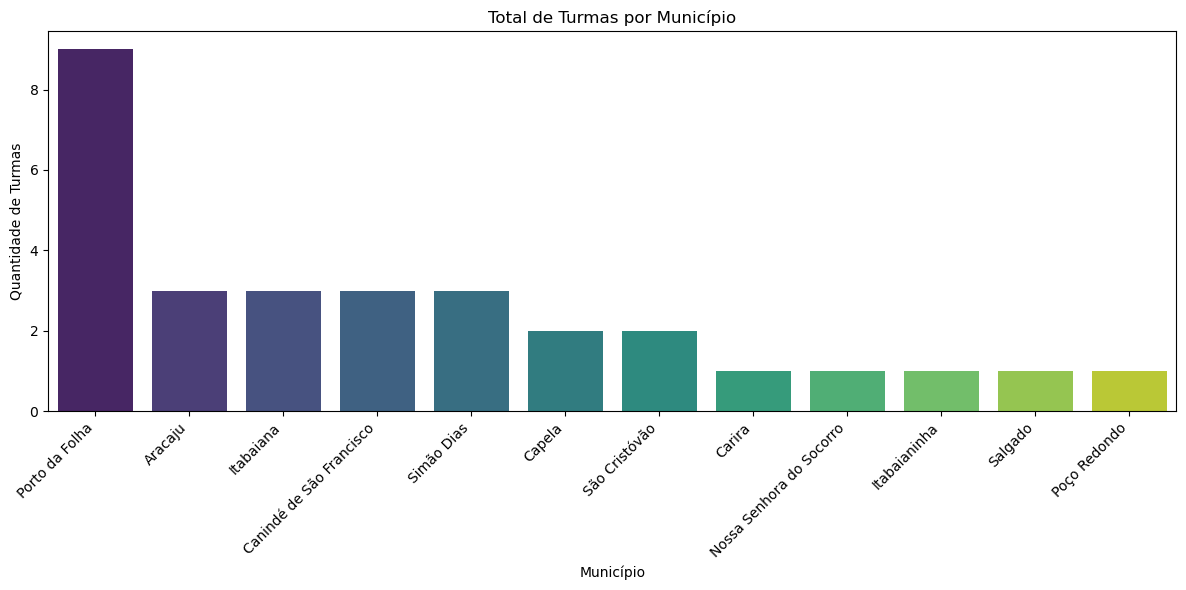

In [13]:
# Criando diretório para salvar os gráficos
output_dir_relatorio_23 = "Data_files/graficos_relatorio_2.3_turmas_aditivo/extra"
os.makedirs(output_dir_relatorio_23, exist_ok=True)

# Criando gráfico de total de turmas por município
plt.figure(figsize=(12, 6))
sns.barplot(data=turmas_por_unidade.sort_values('total_turmas', ascending=False),
            x='municipio',
            y='total_turmas',
            palette='viridis',
            hue='municipio',
            legend=False)
plt.title('Total de Turmas por Município')
plt.xlabel('Município')
plt.ylabel('Quantidade de Turmas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{output_dir_relatorio_23}/total_por_municipio.png', dpi=300)
plt.show()

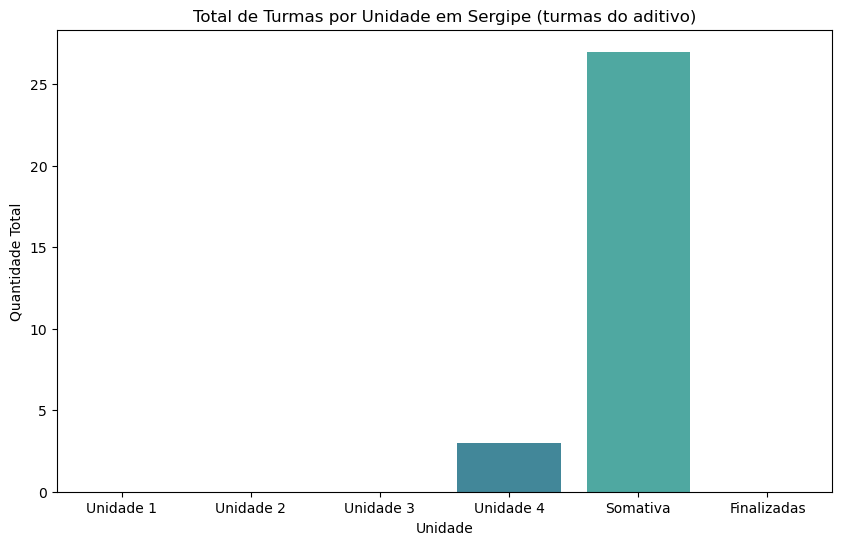

Total de turmas contabilizadas: 30


,municipio,turmas_em_unid_1,turmas_em_unid_2,turmas_em_unid_3,turmas_em_unid_4,turmas_em_somativa,turmas_finalizadas,total_turmas
0,Aracaju,0,0,0,1,2,0,3
1,Canindé de São Francisco,0,0,0,1,2,0,3
2,Capela,0,0,0,0,2,0,2
3,Carira,0,0,0,0,1,0,1
4,Itabaiana,0,0,0,0,3,0,3
5,Itabaianinha,0,0,0,0,1,0,1
6,Nossa Senhora do Socorro,0,0,0,0,1,0,1
7,Porto da Folha,0,0,0,0,9,0,9
8,Poço Redondo,0,0,0,1,0,0,1
9,Salgado,0,0,0,0,1,0,1


In [14]:
# Criando gráfico de total de turmas em cada unidade
# Gráfico 2: Total de turmas por unidade (com rótulos personalizados)
df_unidades = turmas_por_unidade.melt(
    id_vars=['municipio'],
    value_vars=['turmas_em_unid_1', 'turmas_em_unid_2', 'turmas_em_unid_3', 'turmas_em_unid_4', 'turmas_em_somativa', 'turmas_finalizadas'],
    var_name='Unidade',
    value_name='Quantidade'
)

# Mapear nomes das unidades
mapeamento_unidades = {
    'turmas_em_unid_1': 'Unidade 1',
    'turmas_em_unid_2': 'Unidade 2',
    'turmas_em_unid_3': 'Unidade 3',
    'turmas_em_unid_4': 'Unidade 4',
    'turmas_em_somativa': 'Somativa',
    'turmas_finalizadas': 'Finalizadas'
}
df_unidades['Unidade'] = df_unidades['Unidade'].map(mapeamento_unidades)

# Plotar o gráfico (sem warnings!)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_unidades,
    x='Unidade',
    y='Quantidade',
    hue='Unidade',      # Adicionado para evitar o warning
    estimator=sum,
    errorbar=None,
    palette='mako',
    legend=False        # Remove legenda redundante
)
plt.title('Total de Turmas por Unidade em Sergipe (turmas do aditivo)')
plt.xlabel('Unidade')
plt.ylabel('Quantidade Total')
plt.savefig(f'{output_dir_relatorio_23}/total_turmas_por_unidade_sergipe.png', dpi=300)
#plt.close()
plt.show()

print(f"Total de turmas contabilizadas: {turmas_por_unidade['total_turmas'].sum()}")

turmas_por_unidade

In [15]:
# Criando um gráfico por município para mostrar número de turmas em cada unidade
# Criar um gráfico para cada município
for municipio in turmas_por_unidade['municipio'].unique():
    # Filtrar dados do município
    df_municipio = turmas_por_unidade[turmas_por_unidade['municipio'] == municipio]
    
    # Transformar os dados para formato longo (melt) e aplicar mapeamento
    df_melted = df_municipio.melt(
        id_vars=['municipio'], 
        value_vars=['turmas_em_unid_1', 'turmas_em_unid_2', 'turmas_em_unid_3', 'turmas_em_unid_4', 'turmas_em_somativa', 'turmas_finalizadas'],
        var_name='Unidade', 
        value_name='Quantidade'
    )
    
    # Aplicar os novos nomes das unidades
    df_melted['Unidade'] = df_melted['Unidade'].map(mapeamento_unidades)
    
    # Ordenar as unidades
    df_melted['Unidade'] = pd.Categorical(
        df_melted['Unidade'],
        categories=['Unidade 1', 'Unidade 2', 'Unidade 3', 'Unidade 4', 'Somativa', 'Finalizadas'],
        ordered=True
    )
    
    # Configurar o gráfico (versão atualizada do Seaborn)
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=df_melted,
        x='Unidade',
        y='Quantidade',
        hue='Unidade',  # Adicionado para evitar o warning
        palette='rocket',
        legend=False    # Não mostra a legenda redundante
    )
    
    # Adicionar título e rótulos
    plt.title(f'Distribuição de Turmas do Aditivo em {municipio}')
    plt.xlabel('Unidade')
    plt.ylabel('Quantidade de Turmas')
    
    # Salvar o gráfico
    nome_arquivo = f"turmas_por_unidade_{municipio.lower().replace(' ', '_').replace('ã', 'a').replace('ç', 'c')}_aditivo.png"
    plt.tight_layout()
    plt.savefig(f'{output_dir_relatorio_23}/{nome_arquivo}', dpi=300)
    plt.close()


##### Estudando os dados por município
Agora vamos entender os dados de cada município. Dessa forma, nosso objetivo aqui é:
- Entender a quantidade de alunos por município e sua proporção em relação ao programa como um todo;
- Entender a quantidade de turmas por município e sua proporção em relação ao programa como um todo;
- Entender a relevância dos alunos perante o total de alunos enturmados em Sergipe;
- Gerar os resultados dos registros por atividade estruturada por município;
- Gerar os resultados de perfil de turma por município e entender se os perfis são diferentes.

##### Entendendo alunos e turmas por município


#### Atividade Estruturada Formativa 1

Primeiramente, vamos construir uma tabela contando as quantidades de cada nível para cada formativa, considerando a linguagem, municipio e a turma.

In [16]:
# Calculando moda dos níveis para cada linguagem
def calcular_moda_nivel(df, form_number):
    """
    Calcula a moda da coluna 'nivel' para um dataframe de formulário específico.
    
    Args:
        df: DataFrame com os registros do formulário
        form_number: Número do formulário (1, 2, 3, 4 ou 5 para somativa)
    
    Returns:
        DataFrame com as modas calculadas
    """
    moda_df = (
        df.groupby(['cpf', 'nome', 'turma', 'municipio', 'linguagem'])['nivel']
        .agg(lambda x: x.mode().iloc[0])
        .reset_index()
    )
    return moda_df

# Calcular modas para cada formulário
moda_form_1 = calcular_moda_nivel(df_registros_form_1, 1)
moda_form_2 = calcular_moda_nivel(df_registros_form_2, 2)
moda_form_3 = calcular_moda_nivel(df_registros_form_3, 3)
moda_form_4 = calcular_moda_nivel(df_registros_form_4, 4)
moda_somativa = calcular_moda_nivel(df_registros_soma, 5)

# Contando níveis por formativa
def contar_niveis_por_form(df, form_number):
    # Conta a ocorrência de cada nível, mantendo as colunas de agrupamento
    # Adicionando observed=True para evitar o warning
    contagem = (
        df.groupby(['turma', 'municipio', 'linguagem', 'nivel'], observed=True)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    
    # Renomeia as colunas de nível para incluir o número do formulário
    nivel_cols = [col for col in contagem.columns if col not in ['turma', 'municipio', 'linguagem']]
    rename_dict = {col: f'form_{form_number}_{col}' for col in nivel_cols}
    contagem = contagem.rename(columns=rename_dict)
    
    return contagem

# Aplicar a função para cada formulário
contagem_form_1 = contar_niveis_por_form(moda_form_1, 1)
contagem_form_2 = contar_niveis_por_form(moda_form_2, 2)
contagem_form_3 = contar_niveis_por_form(moda_form_3, 3)
contagem_form_4 = contar_niveis_por_form(moda_form_4, 4)
contagem_somativa = contar_niveis_por_form(moda_somativa, 'somativa')  

# Combinar os resultados com outer join
df_contagem_completa = (
    contagem_form_1
    .merge(contagem_form_2, 
           on=['turma', 'municipio', 'linguagem'], 
           how='outer',
           suffixes=('', '_form2'))
    .merge(contagem_form_3, 
           on=['turma', 'municipio', 'linguagem'],
           how='outer',
           suffixes=('', '_form3'))
    .merge(contagem_form_4, 
           on=['turma', 'municipio', 'linguagem'],
           how='outer',
           suffixes=('', '_form4'))
    .merge(contagem_somativa, 
           on=['turma', 'municipio', 'linguagem'],
           how='outer',
           suffixes=('', '_somativa'))
    .fillna(0)
)

# Limpeza final dos nomes das colunas
df_contagem_completa.columns = [col.replace('_form2', '_form_2').replace('_form3', '_form_3').replace('_form4', '_form_4').replace('_form_5', '_somativa') 
                               for col in df_contagem_completa.columns]

# Ordenação final
df_contagem_completa = df_contagem_completa.sort_values(
    by=['turma', 'municipio', 'linguagem']
).reset_index(drop=True)

# Separando por linguagem
#df_analise_linguistica = df_contagem_completa[df_contagem_completa['linguagem'] == 'Análise linguística'].drop(['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3', 'form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3', 'form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3'], axis=1, errors='ignore').reset_index(drop=True)
df_oralidade_leitura_13 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3', 'form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3'], axis=1, errors='ignore').reset_index(drop=True)
#df_oralidade_leitura_14 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3', 'form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3'], axis=1, errors='ignore').reset_index(drop=True)
# df_oralidade_leitura_15 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3', 'form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3'], axis=1, errors='ignore').reset_index(drop=True)
#df_oralidade_leitura_34 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3'], axis=1, errors='ignore').reset_index(drop=True)
# df_oralidade_leitura_35 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3'], axis=1, errors='ignore').reset_index(drop=True)
# df_oralidade_leitura_45 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3'], axis=1, errors='ignore').reset_index(drop=True)
#df_producao_escrita_34 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Produção escrita'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3'], axis=1, errors='ignore').reset_index(drop=True)
# df_producao_escrita_35 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Produção escrita'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3'], axis=1, errors='ignore').reset_index(drop=True)
# df_producao_escrita_45 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Produção escrita'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3'], axis=1, errors='ignore').reset_index(drop=True)

# Contando número total de alunos por turma com base na Formativa 1
#df_analise_linguistica['total_alunos_form_1'] = df_analise_linguistica[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
#df_analise_linguistica['total_alunos_form_2'] = df_analise_linguistica[['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3']].sum(axis=1)
df_oralidade_leitura_13['total_alunos_form_1'] = df_oralidade_leitura_13[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
df_oralidade_leitura_13['total_alunos_form_3'] = df_oralidade_leitura_13[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
#df_oralidade_leitura_14['total_alunos_form_1'] = df_oralidade_leitura_14[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
#df_oralidade_leitura_14['total_alunos_form_4'] = df_oralidade_leitura_14[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)
#df_oralidade_leitura_15['total_alunos_form_1'] = df_oralidade_leitura_15[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
#df_oralidade_leitura_15['total_alunos_form_somativa'] = df_oralidade_leitura_15[['form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3']].sum(axis=1)
#df_oralidade_leitura_34['total_alunos_form_3'] = df_oralidade_leitura_34[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
#df_oralidade_leitura_34['total_alunos_form_4'] = df_oralidade_leitura_34[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)
#df_oralidade_leitura_35['total_alunos_form_3'] = df_oralidade_leitura_35[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
#df_oralidade_leitura_35['total_alunos_form_somativa'] = df_oralidade_leitura_35[['form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3']].sum(axis=1)
#df_oralidade_leitura_45['total_alunos_form_4'] = df_oralidade_leitura_45[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)
#df_oralidade_leitura_45['total_alunos_form_somativa'] = df_oralidade_leitura_45[['form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3']].sum(axis=1)
#df_producao_escrita_34['total_alunos_form_3'] = df_producao_escrita_34[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
#df_producao_escrita_34['total_alunos_form_4'] = df_producao_escrita_34[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)
#df_producao_escrita_35['total_alunos_form_3'] = df_producao_escrita_35[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
#df_producao_escrita_35['total_alunos_form_somativa'] = df_producao_escrita_35[['form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3']].sum(axis=1)
#df_producao_escrita_45['total_alunos_form_4'] = df_producao_escrita_45[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)
#df_producao_escrita_45['total_alunos_form_somativa'] = df_producao_escrita_45[['form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3']].sum(axis=1)

# Calcular proporções para cada nível em cada teste
for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
    #df_analise_linguistica[f'prop_form_1_{nivel}'] = df_analise_linguistica[f'form_1_{nivel}'] / df_analise_linguistica['total_alunos_form_1']
    #df_analise_linguistica[f'prop_form_2_{nivel}'] = df_analise_linguistica[f'form_2_{nivel}'] / df_analise_linguistica['total_alunos_form_2']
    df_oralidade_leitura_13[f'prop_form_1_{nivel}'] = df_oralidade_leitura_13[f'form_1_{nivel}'] / df_oralidade_leitura_13['total_alunos_form_1']
    df_oralidade_leitura_13[f'prop_form_3_{nivel}'] = df_oralidade_leitura_13[f'form_3_{nivel}'] / df_oralidade_leitura_13['total_alunos_form_3']
    #df_oralidade_leitura_14[f'prop_form_1_{nivel}'] = df_oralidade_leitura_14[f'form_1_{nivel}'] / df_oralidade_leitura_14['total_alunos_form_4']
    #df_oralidade_leitura_14[f'prop_form_4_{nivel}'] = df_oralidade_leitura_14[f'form_4_{nivel}'] / df_oralidade_leitura_14['total_alunos_form_4']
    #df_oralidade_leitura_15[f'prop_form_1_{nivel}'] = df_oralidade_leitura_15[f'form_1_{nivel}'] / df_oralidade_leitura_15['total_alunos_form_somativa']
    #df_oralidade_leitura_15[f'prop_form_somativa_{nivel}'] = df_oralidade_leitura_15[f'form_somativa_{nivel}'] / df_oralidade_leitura_15['total_alunos_form_somativa']
    #df_oralidade_leitura_34[f'prop_form_3_{nivel}'] = df_oralidade_leitura_34[f'form_3_{nivel}'] / df_oralidade_leitura_34['total_alunos_form_3']
    #df_oralidade_leitura_34[f'prop_form_4_{nivel}'] = df_oralidade_leitura_34[f'form_4_{nivel}'] / df_oralidade_leitura_34['total_alunos_form_4']
    #df_oralidade_leitura_35[f'prop_form_3_{nivel}'] = df_oralidade_leitura_35[f'form_3_{nivel}'] / df_oralidade_leitura_35['total_alunos_form_3']
    #df_oralidade_leitura_35[f'prop_form_somativa_{nivel}'] = df_oralidade_leitura_35[f'form_somativa_{nivel}'] / df_oralidade_leitura_35['total_alunos_form_somativa']
    #df_oralidade_leitura_45[f'prop_form_4_{nivel}'] = df_oralidade_leitura_45[f'form_4_{nivel}'] / df_oralidade_leitura_45['total_alunos_form_4']
    #df_oralidade_leitura_45[f'prop_form_somativa_{nivel}'] = df_oralidade_leitura_45[f'form_somativa_{nivel}'] / df_oralidade_leitura_45['total_alunos_form_somativa']
    #df_producao_escrita_34[f'prop_form_3_{nivel}'] = df_producao_escrita_34[f'form_3_{nivel}'] / df_producao_escrita_34['total_alunos_form_3']
    #df_producao_escrita_34[f'prop_form_4_{nivel}'] = df_producao_escrita_34[f'form_4_{nivel}'] / df_producao_escrita_34['total_alunos_form_4']
    #df_producao_escrita_35[f'prop_form_3_{nivel}'] = df_producao_escrita_35[f'form_3_{nivel}'] / df_producao_escrita_35['total_alunos_form_3']
    #df_producao_escrita_35[f'prop_form_somativa_{nivel}'] = df_producao_escrita_35[f'form_somativa_{nivel}'] / df_producao_escrita_35['total_alunos_form_somativa']
    #df_producao_escrita_45[f'prop_form_4_{nivel}'] = df_producao_escrita_45[f'form_4_{nivel}'] / df_producao_escrita_45['total_alunos_form_4']
    #df_producao_escrita_45[f'prop_form_somativa_{nivel}'] = df_producao_escrita_45[f'form_somativa_{nivel}'] / df_producao_escrita_45['total_alunos_form_somativa']


In [17]:
# Checando dados NaN no dataframe
#zero_analise_linguistica_form_1 = (df_analise_linguistica['total_alunos_form_1'] == 0).sum()
#zero_analise_linguistica_form_2 = (df_analise_linguistica['total_alunos_form_2'] == 0).sum()
zero_oralidade_leitura_13_form_1 = (df_oralidade_leitura_13['total_alunos_form_1'] == 0).sum()
zero_oralidade_leitura_13_form_3 = (df_oralidade_leitura_13['total_alunos_form_3'] == 0).sum()
#zero_oralidade_leitura_14_form_1 = (df_oralidade_leitura_14['total_alunos_form_1'] == 0).sum()
#zero_oralidade_leitura_14_form_4 = (df_oralidade_leitura_14['total_alunos_form_4'] == 0).sum()
#zero_oralidade_leitura_15_form_1 = (df_oralidade_leitura_15['total_alunos_form_1'] == 0).sum()
#zero_oralidade_leitura_15_form_somativa = (df_oralidade_leitura_15['total_alunos_form_somativa'] == 0).sum()
#zero_oralidade_leitura_34_form_3 = (df_oralidade_leitura_34['total_alunos_form_3'] == 0).sum()
#zero_oralidade_leitura_34_form_4 = (df_oralidade_leitura_34['total_alunos_form_4'] == 0).sum()
#zero_oralidade_leitura_35_form_3 = (df_oralidade_leitura_35['total_alunos_form_3'] == 0).sum()
#zero_oralidade_leitura_35_form_somativa = (df_oralidade_leitura_35['total_alunos_form_somativa'] == 0).sum()
#zero_oralidade_leitura_45_form_4 = (df_oralidade_leitura_45['total_alunos_form_4'] == 0).sum()
#zero_oralidade_leitura_45_form_somativa = (df_oralidade_leitura_45['total_alunos_form_somativa'] == 0).sum()
#zero_producao_escrita_34_form_3 = (df_producao_escrita_34['total_alunos_form_3'] == 0).sum()
#zero_producao_escrita_34_form_4 = (df_producao_escrita_34['total_alunos_form_4'] == 0).sum()
#zero_producao_escrita_35_form_3 = (df_producao_escrita_35['total_alunos_form_3'] == 0).sum()
#zero_producao_escrita_35_form_somativa = (df_producao_escrita_35['total_alunos_form_somativa'] == 0).sum()
#zero_producao_escrita_45_form_4 = (df_producao_escrita_45['total_alunos_form_4'] == 0).sum()
#zero_producao_escrita_45_form_somativa = (df_producao_escrita_45['total_alunos_form_somativa'] == 0).sum()


# Imprimindo resultados
#print(f"Análise Linguística - Formativa 1 com zero alunos: {zero_analise_linguistica_form_1}")
#print(f"Análise Linguística - Formativa 2 com zero alunos: {zero_analise_linguistica_form_2}")
print(f"Oralidade e Leitura 13 - Formativa 1 com zero alunos: {zero_oralidade_leitura_13_form_1}")
print(f"Oralidade e Leitura 13 - Formativa 3 com zero alunos: {zero_oralidade_leitura_13_form_3}")
#print(f"Oralidade e Leitura 14 - Formativa 1 com zero alunos: {zero_oralidade_leitura_14_form_1}")
#print(f"Oralidade e Leitura 14 - Formativa 4 com zero alunos: {zero_oralidade_leitura_14_form_4}")
#print(f"Oralidade e Leitura 15 - Formativa 1 com zero alunos: {zero_oralidade_leitura_15_form_1}")
#print(f"Oralidade e Leitura 15 - Somativa com zero alunos: {zero_oralidade_leitura_15_form_somativa}")
#print(f"Oralidade e Leitura 34 - Formativa 3 com zero alunos: {zero_oralidade_leitura_34_form_3}")
#print(f"Oralidade e Leitura 34 - Formativa 4 com zero alunos: {zero_oralidade_leitura_34_form_4}")
#print(f"Oralidade e Leitura 35 - Formativa 3 com zero alunos: {zero_oralidade_leitura_35_form_3}")
#print(f"Oralidade e Leitura 35 - Somativa com zero alunos: {zero_oralidade_leitura_35_form_somativa}")
#print(f"Oralidade e Leitura 45 - Formativa 4 com zero alunos: {zero_oralidade_leitura_45_form_4}")
#print(f"Oralidade e Leitura 45 - Somativa com zero alunos: {zero_oralidade_leitura_45_form_somativa}")
#print(f"Produção Escrita 34 - Formativa 3 com zero alunos: {zero_producao_escrita_34_form_3}")
#print(f"Produção Escrita 34 - Formativa 4 com zero alunos: {zero_producao_escrita_34_form_4}")
#print(f"Produção Escrita 35 - Formativa 3 com zero alunos: {zero_producao_escrita_35_form_3}")
#print(f"Produção Escrita 35 - Somativa com zero alunos: {zero_producao_escrita_35_form_somativa}")
#print(f"Produção Escrita 45 - Formativa 4 com zero alunos: {zero_producao_escrita_45_form_4}")
#print(f"Produção Escrita 45 - Somativa com zero alunos: {zero_producao_escrita_45_form_somativa}")

Oralidade e Leitura 13 - Formativa 1 com zero alunos: 0
Oralidade e Leitura 13 - Formativa 3 com zero alunos: 0


In [18]:
# Removendo NaN (turmas que não apresentam todos os dados para comparação)
#df_analise_linguistica = df_analise_linguistica.dropna()
df_oralidade_leitura_13 = df_oralidade_leitura_13.dropna()
#df_oralidade_leitura_14 = df_oralidade_leitura_14.dropna()
#df_oralidade_leitura_15 = df_oralidade_leitura_15.dropna()
#df_oralidade_leitura_34 = df_oralidade_leitura_34.dropna()
#df_oralidade_leitura_35 = df_oralidade_leitura_35.dropna()
#df_oralidade_leitura_45 = df_oralidade_leitura_45.dropna()
#df_producao_escrita_34 = df_producao_escrita_34.dropna()
#df_producao_escrita_35 = df_producao_escrita_35.dropna()
#df_producao_escrita_45 = df_producao_escrita_45.dropna()

#### Gerando dados por Prática de Linguagem separadamente

In [19]:
# Criando função para gerar gráficos com dados por prática de linguagem
def criar_graficos_por_pratica_estado(df, form_a, output_dir, pratica, cor_grafico, denominador=""):
    """
    Gera gráfico para uma prática de linguagem específica
    
    Argumentos:
        df: DataFrame com dados de alunos (contagem_form_1, contagem_form_2, contagem_form_3, contagem_form_4, contagem_somativa)
        form_a: String com nome da formativa (form_1, form_2, form_3, form_4, somativa)
        output_dir: Variável com diretório onde salvar o gráfico
        pratica: String com nome da prática de linguagem (Análise linguística, Oralidade e leitura, Produção escrita)
        cor_grafico: Cor do gráfico (verde, amarelo, cinza_claro, cinza_fundo)
        denominador: String com o nome do denominador em caso de turmas focais. Padrão: ""
        
    """

    # Configuração do estilo com tema elegante usando cores do Rio Grande do Norte
    sns.set_style("whitegrid")
    plt.rcParams['font.family'] = 'DejaVu Sans'

    # Cores da bandeira do RN
    if cor_grafico == 'verde':
        cor = '#009639'  # Verde oficial
    elif cor_grafico == 'amarelo':
        cor = '#FEDF00'  # Amarelo oficial
    elif cor_grafico == 'cinza_claro':
        cor = '#f5f5f5'
    elif cor_grafico == 'cinza_fundo':
        cor = '#fafafa'
    
    cinza_claro = '#f5f5f5'

    # Função para criar e salvar gráficos individuais
    # Filtrar e somar os dados
    dados_filtrados = df[df['linguagem'] == pratica]
    soma_niveis = dados_filtrados[[f'{form_a}_Nível 1', f'{form_a}_Nível 2', f'{form_a}_Nível 3']].sum()
    
    # Criar DataFrame para o gráfico
    df_grafico = pd.DataFrame({
        'Nível': ['Nível 1', 'Nível 2', 'Nível 3'],
        'Quantidade': soma_niveis.values
        })
    
    # Criar figura
    plt.figure(figsize=(10, 8))
    ax = plt.gca()
    
    # Criar gráfico de barras
    bars = sns.barplot(
        data=df_grafico,
        x='Nível',
        y='Quantidade',
        color=cor,
        edgecolor='white',
        linewidth=2,
        alpha=0.9
        )
    
    # Personalizar título e labels
    titulo = f'{pratica}'.upper()
    if denominador == "":
        titulo2 = 'Total de Alunos por Nível'
    else:
        titulo2 = f'{denominador} - Alunos por Nível'
    
    plt.title(f'{titulo}\n{titulo2}', 
              fontsize=16, fontweight='bold', pad=20, color='#333333')
    plt.xlabel('Níveis de Desempenho', fontsize=12, fontweight='bold', color='#555555')
    plt.ylabel('Quantidade de Alunos', fontsize=12, fontweight='bold', color='#555555')
    
    # Personalizar eixos
    ax.set_facecolor(cinza_claro)
    ax.tick_params(axis='both', which='major', labelsize=11)
    
    # Adicionar valores nas barras
    max_val = df_grafico['Quantidade'].max()
    for i, valor in enumerate(df_grafico['Quantidade']):
        plt.text(i, valor + max_val * 0.01, f'{valor}', 
                 ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333333')
    
    # Ajustar limite do eixo Y
    plt.ylim(0, max_val * 1.15)
    
    # Adicionar grid sutil
    plt.grid(True, alpha=0.3)
    
    # Ajustar layout
    plt.tight_layout()
    
    # Salvar gráfico
    caminho_completo = os.path.join(output_dir, f'grafico_{pratica}.png'
                                    .replace(' ', '_')
                                    .replace('á', 'a')
                                    .replace('í', 'i')
                                    .replace('ç', 'c')
                                    .replace('ã', 'a')
                                    .replace(' e ', '_')
                                    .lower()
                                    )
    # Salvando gráfico
    plt.savefig(caminho_completo, dpi=300, bbox_inches='tight', facecolor='white')
    
    # Exibindo resultados
    print(f"Gráfico salvo: {caminho_completo}")
    plt.show()
    plt.close()


Gráfico salvo: Data_files/graficos_relatorio_2.3_turmas_aditivo/extra/grafico_producao_escrita.png


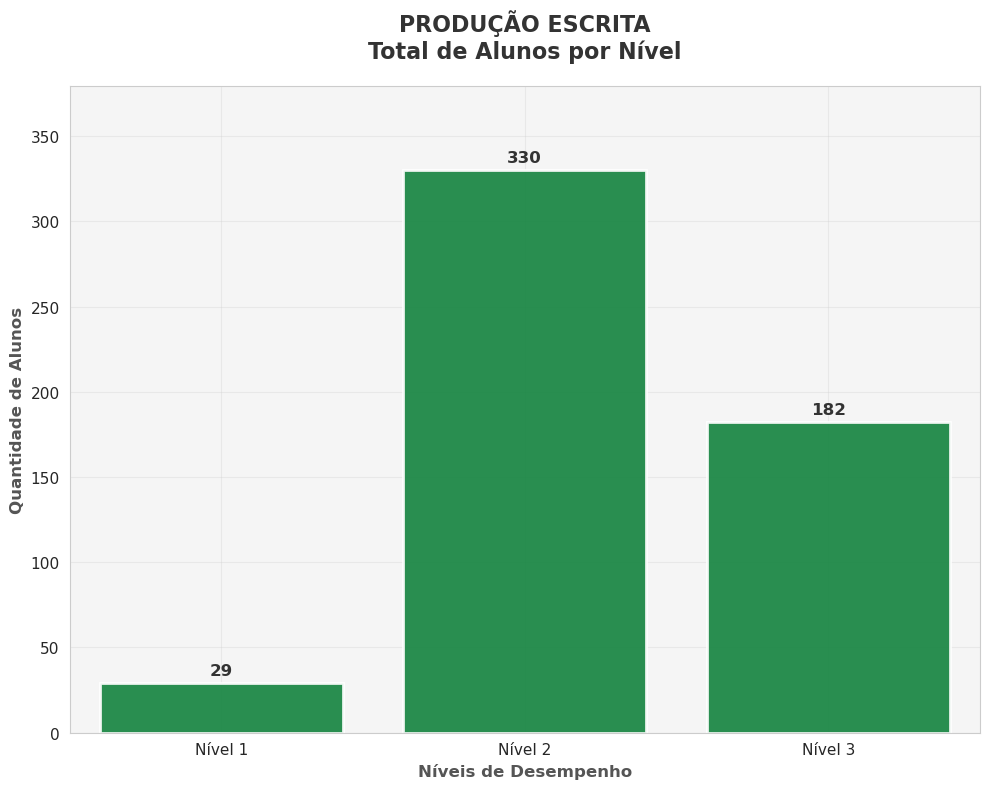

In [20]:
# Aplicando função para gerar gráficos com dados por prática de linguagem
#criar_graficos_por_pratica_estado(contagem_form_1, 'form_1', output_dir_relatorio_21, 'Análise linguística', 'amarelo')
#criar_graficos_por_pratica_estado(contagem_form_1, 'form_1', output_dir_relatorio_21, 'Oralidade e leitura', 'verde')
criar_graficos_por_pratica_estado(contagem_form_3, 'form_3', output_dir_relatorio_23, 'Produção escrita', 'verde')


In [21]:
# Configuração do estilo
sns.set_style("white")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titleweight'] = 'bold'

# Definindo cores
verde = '#009639'  # Verde oficial
cinza_fundo = '#fafafa'

# Função para criar gráfico por município e linguagem
def criar_grafico_denominador_linguagem(df, nome_coluna, valor, linguagem, cor, output_dir):
    """Cria gráfico para um denominador (municipio ou categoria) e linguagem específicos"""
    
    # O filtro agora usa o nome da coluna 'denominador' (string) e
    # compara com a variável 'denominador' (que contém o valor).
    dados_filtrados = df[
        (df[nome_coluna] == valor) & 
        (df['linguagem'] == linguagem)
    ]
    
    if dados_filtrados.empty:
        return
    
    # Somar os níveis (pode haver múltiplas turmas no mesmo município)
    soma_niveis = dados_filtrados[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum()
    
    # Criar figura
    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor('white')
    
    # Criar gráfico de barras
    bars = ax.bar(['NÍVEL 1', 'NÍVEL 2', 'NÍVEL 3'], soma_niveis.values,
                 color=cor, alpha=0.85, edgecolor='white', linewidth=2.5)
    
    # Configurações do gráfico
    ax.set_facecolor(cinza_fundo)
    
    # Título baseado na linguagem
    titulo = f'{linguagem}\n{valor.replace('turma', 'turmas').replace('bilíngue', 'bilíngues').replace('quilombola', 'quilombolas').replace('indígena', 'indígenas')}'.upper()
    filename = f'{linguagem}_{valor}.png'.lower().replace(" ", "_").replace("á", "a").replace("í", "i").replace("ç", "c").replace("ã", "a").replace(" e ", "_")

    ax.set_title(titulo, fontsize=16, pad=20, color='#2d2d2d')
    ax.set_ylabel('QUANTIDADE DE ALUNOS', fontsize=12, color='#555555')
    ax.set_xlabel('NÍVEIS DE DESEMPENHO', fontsize=12, color='#555555')
    
    # Estilizar eixos
    ax.tick_params(axis='x', labelsize=11, labelcolor='#444444')
    ax.tick_params(axis='y', labelsize=10, labelcolor='#666666')
    
    # Remover bordas desnecessárias
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color('#dddddd')
    
    # Adicionar valores nas barras
    max_val = max(soma_niveis.values) if max(soma_niveis.values) > 0 else 1
    for i, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0:  # Só adiciona texto se houver valor
            ax.text(bar.get_x() + bar.get_width()/2., height + max_val*0.02,
                   f'{int(height)}', ha='center', va='bottom', 
                   fontsize=11, fontweight='bold', color='#2d2d2d')
    
    # Grid sutil
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    
    # Ajustar limite do eixo Y
    ax.set_ylim(0, max_val * 1.15)
    
    # Layout
    plt.tight_layout()
    
    # Salvar gráfico
    caminho_completo = os.path.join(output_dir, filename)
    plt.savefig(caminho_completo, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    
    return filename


In [22]:
# Criamos a nova coluna 'denominador' no DataFrame.
#contagem_form_3['denominador'] = contagem_form_3['municipio'].fillna(contagem_form_3['categoria'])

# Usamos np.concatenate() para JUNTAR os arrays, em vez de '+' que tenta SOMÁ-LOS.
#denominadores = np.concatenate((municipios, categorias))

# Criar gráficos para todos os denominadores
municipios = df_registros['municipio'].unique()
graficos_criados = []

for municipio in municipios:
    print(f"💾 Criando gráficos para: {municipio}")
    
    # Gráfico de Produção escrita
    arquivo_producao_escrita = criar_grafico_denominador_linguagem(contagem_form_3, 
                                                                   'municipio', municipio, 'Produção escrita', verde, output_dir_relatorio_23
    )
    if arquivo_producao_escrita:
        graficos_criados.append(arquivo_producao_escrita)

# Relatório final
print(f"\n✅ Processo concluído!")
print(f"📁 Diretório: {output_dir_relatorio_23}")
print(f"📊 Total de gráficos criados: {len(graficos_criados)}")
print(f"🏙️  Denominadores processados: {len(municipios)}")

# Imprimindo contagem por nível
contagem_form_3[contagem_form_3['linguagem'] == "Produção escrita"].groupby('municipio')[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum()

💾 Criando gráficos para: Canindé de São Francisco
💾 Criando gráficos para: Porto da Folha
💾 Criando gráficos para: Simão Dias
💾 Criando gráficos para: Aracaju
💾 Criando gráficos para: Itabaianinha
💾 Criando gráficos para: Nossa Senhora do Socorro
💾 Criando gráficos para: Itabaiana
💾 Criando gráficos para: São Cristóvão
💾 Criando gráficos para: Salgado
💾 Criando gráficos para: Poço Redondo
💾 Criando gráficos para: Carira
💾 Criando gráficos para: Capela

✅ Processo concluído!
📁 Diretório: Data_files/graficos_relatorio_2.3_turmas_aditivo/extra
📊 Total de gráficos criados: 12
🏙️  Denominadores processados: 12


nivel,form_3_Nível 1,form_3_Nível 2,form_3_Nível 3
municipio,,,
Aracaju,8,37,6
Canindé de São Francisco,7,24,22
Capela,0,8,14
Carira,3,8,7
Itabaiana,5,51,8
Itabaianinha,0,10,1
Nossa Senhora do Socorro,0,0,24
Porto da Folha,0,80,78
Poço Redondo,0,21,4


#### Teste Estatĩstico

##### Oralidade e Leitura

Agora vamos realizar o mesmo teste estatístico para Oralidade e Leitura e Produção Escrita

In [23]:
# Criando função para análise estatística (Wilcoxon) para o estado de Sergipe
def teste_wilcoxon(df, form_a, form_b, output_dir, df_name):
    # Tradutor de nomes de práticas de linguagem
    label_praticas = {
        'df_analise_linguistica': 'Análise Linguística',
        'df_oralidade_leitura_13':'Oralidade e Leitura',
        'df_oralidade_leitura_14':'Oralidade e Leitura',
        'df_oralidade_leitura_15':'Oralidade e Leitura',
        'df_oralidade_leitura_34':'Oralidade e Leitura',
        'df_oralidade_leitura_35':'Oralidade e Leitura',
        'df_oralidade_leitura_45':'Oralidade e Leitura',
        'df_producao_escrita_34': 'Produção Escrita',
        'df_producao_escrita_35': 'Produção Escrita',
        'df_producao_escrita_45': 'Produção Escrita',
    }
    
    # Tradutor de nomes de formativas
    label_formativas = {
        'form_1': 'Formativa 1',
        'form_2': 'Formativa 2',
        'form_3': 'Formativa 3',
        'form_4': 'Formativa 4',
        'form_somativa': 'Somativa'
        }
    
    # Buscando label no dicinário
    label_a = label_formativas.get(form_a, form_a)
    label_b = label_formativas.get(form_b, form_b)
    label_pratica_correta = label_praticas.get(df_name, df_name)
    
    # 1. Análise para todo o estado
    print(f"\n=== ANÁLISE CONSIDERANDO {label_pratica_correta} ({label_a} E {label_b}) PARA TODO O ESTADO DE SERGIPE ===\n")
    
    # Teste de Wilcoxon para amostras pareadas (comparando as proporções de cada turma)
    for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
        stat, p = wilcoxon(df[f'prop_{form_a}_{nivel}'], 
                           df[f'prop_{form_b}_{nivel}'])
        print(f"\n{nivel}:")
        print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
        if p < 0.05:
            print(f"Há diferença significativa (p < 0.05) nas proporções de {nivel} entre os testes.")
            # Verificar a direção da diferença
            median_diff = (df[f'prop_{form_b}_{nivel}'] - df[f'prop_{form_a}_{nivel}']).median()
            if median_diff > 0:
                print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
            else:
                print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
        else:
            print(f"Não há diferença significativa (p ≥ 0.05) nas proporções de {nivel} entre os testes.")
    
    # 2. Análise por município
    print(f"\n=== ANÁLISE CONSIDERANDO {label_pratica_correta} (FORMATIVAS {label_a} E {label_b}) POR MUNICÍPIO ===\n")
    
    for municipio in df['municipio'].unique():
        print(f"\nMunicípio: {municipio}")
        df_municipio = df[df['municipio'] == municipio]
        
        if len(df_municipio) < 3:  # Muito poucas turmas para análise
            print("Número de turmas insuficiente para análise estatística.")
            continue
        
        for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
            stat, p = wilcoxon(df_municipio[f'prop_{form_a}_{nivel}'], 
                               df_municipio[f'prop_{form_b}_{nivel}'])
            print(f"\n{nivel}:")
            print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
            if p < 0.05:
                print(f"Há diferença significativa (p < 0.05) em {municipio}.")
                median_diff = (df_municipio[f'prop_{form_b}_{nivel}'] - df_municipio[f'prop_{form_a}_{nivel}']).median()
                if median_diff > 0:
                    print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
                else:
                    print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
            else:
                print(f"Não há diferença significativa (p ≥ 0.05) em {municipio}.")
            
    # 3. Análise de transição entre níveis (para todo o estado)
    print(f"\n=== ANÁLISE DE TRANSIÇÃO ENTRE NÍVEIS PARA {label_pratica_correta} (ESTADO) ===\n")
    
    # Calcular totais estaduais para cada nível
    totais_estado = {
        f'{form_a}_Nível 1': df[f'{form_a}_Nível 1'].sum(),
        f'{form_a}_Nível 2': df[f'{form_a}_Nível 2'].sum(),
        f'{form_a}_Nível 3': df[f'{form_a}_Nível 3'].sum(),
        f'{form_b}_Nível 1': df[f'{form_b}_Nível 1'].sum(),
        f'{form_b}_Nível 2': df[f'{form_b}_Nível 2'].sum(),
        f'{form_b}_Nível 3': df[f'{form_b}_Nível 3'].sum(),
        f'total_{form_a}': df[f'total_alunos_{form_a}'].sum(),
        f'total_{form_b}': df[f'total_alunos_{form_b}'].sum()
    }
    
    # Teste qui-quadrado para tabelas de contingência (comparando distribuição dos níveis)
    print("Teste qui-quadrado para distribuição dos níveis entre form_1 e form_3:")
    
    # Criar tabela de contingência
    contingency_table = np.array([
        [totais_estado[f'{form_a}_Nível 1'], totais_estado[f'{form_a}_Nível 2'], totais_estado[f'{form_a}_Nível 3']],
        [totais_estado[f'{form_b}_Nível 1'], totais_estado[f'{form_b}_Nível 2'], totais_estado[f'{form_b}_Nível 3']]
    ])
    
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"Qui-quadrado = {chi2:.3f}, p-valor = {p:.4f}")
    if p < 0.05:
        print("Há diferença significativa (p < 0.05) na distribuição dos níveis entre os testes.")
        print("Tabela observada:")
        print(contingency_table)
        print("\nTabela esperada sob a hipótese nula:")
        print(expected.round(1))
        
        # Calcular resíduos padronizados para identificar onde estão as diferenças
        residuals = (contingency_table - expected) / np.sqrt(expected)
        print("\nResíduos padronizados (valores absolutos >2 indicam diferenças significativas):")
        print(residuals.round(2))
    else:
        print("Não há diferença significativa (p ≥ 0.05) na distribuição dos níveis entre os testes.")
    
    plt.figure(figsize=(12, 6))
    
    # Proporções estaduais
    prop_form_a = [totais_estado[f'{form_a}_Nível 1']/totais_estado[f'total_{form_a}'],
                   totais_estado[f'{form_a}_Nível 2']/totais_estado[f'total_{form_a}'],
                   totais_estado[f'{form_a}_Nível 3']/totais_estado[f'total_{form_a}']]
    
    prop_form_b = [totais_estado[f'{form_b}_Nível 1']/totais_estado[f'total_{form_b}'],
                   totais_estado[f'{form_b}_Nível 2']/totais_estado[f'total_{form_b}'],
                   totais_estado[f'{form_b}_Nível 3']/totais_estado[f'total_{form_b}']]
    
    # Calcular erros padrão para cada proporção
    # Para proporções, o erro padrão é sqrt(p*(1-p)/n)
    def calc_erro_proporcao(p, n):
        return np.sqrt(p * (1 - p) / n)
    
    erro_form_a = [calc_erro_proporcao(p, totais_estado[f'total_{form_a}']) for p in prop_form_a]
    erro_form_b = [calc_erro_proporcao(p, totais_estado[f'total_{form_b}']) for p in prop_form_b]
    
    bar_width = 0.35
    index = np.arange(3)
    
    # Criar barras com erro
    bars1 = plt.bar(index, prop_form_a, bar_width, label=label_a, alpha=0.8, color='#1f77b4',
                    yerr=erro_form_a, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})
    
    bars2 = plt.bar(index + bar_width, prop_form_b, bar_width, label=label_b, alpha=0.8, color='#ff7f0e',
                    yerr=erro_form_b, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})
                
    # Adicionar valores nas barras
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.03,  # Adicione um offset de 0.02 (2%)
                    f'{height:.1%}',
                    ha='center', va='bottom', fontsize=10)
            
    #Testar cada nível separadamente com Wilcoxon
    niveis_significativos = []
    for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
        stat, p_nivel = wilcoxon(df[f'prop_{form_a}_{nivel}'], 
                                df[f'prop_{form_b}_{nivel}'])
        if p_nivel < 0.05:
            niveis_significativos.append(i)
            y_pos = max(prop_form_a[i], prop_form_b[i]) + 0.05
            plt.text(index[i] + bar_width/2, y_pos, '*', 
                    ha='center', va='bottom', fontsize=16, color='red')
            
    # Personalizar
    plt.xlabel('Níveis', fontsize=12)
    plt.ylabel('Proporção de Alunos', fontsize=12)
    plt.title(f'Comparação das Proporções por Nível para {label_pratica_correta} ({label_a} e {label_b})- Estado de Sergipe\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=14)
    plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(0, max(prop_form_a + prop_form_b) + 0.15)  # Ajuste para acomodar as barras de erro
    
    # Salvando gráfico
    plt.savefig(f'{output_dir}/teste_wilcoxon_{df_name}_Sergipe.png', dpi=300)
    
    # Exibindo gráfico
    plt.tight_layout()
    plt.show()
    


=== ANÁLISE CONSIDERANDO Oralidade e Leitura (Formativa 1 E Formativa 3) PARA TODO O ESTADO DE SERGIPE ===


Nível 1:
Estatística = 23.500, p-valor = 0.0001
Há diferença significativa (p < 0.05) nas proporções de Nível 1 entre os testes.
A proporção de alunos no Nível 1 DIMINUIU significativamente no teste 2.

Nível 2:
Estatística = 199.500, p-valor = 0.4973
Não há diferença significativa (p ≥ 0.05) nas proporções de Nível 2 entre os testes.

Nível 3:
Estatística = 42.000, p-valor = 0.0061
Há diferença significativa (p < 0.05) nas proporções de Nível 3 entre os testes.
A proporção de alunos no Nível 3 AUMENTOU significativamente no teste 2.

=== ANÁLISE CONSIDERANDO Oralidade e Leitura (FORMATIVAS Formativa 1 E Formativa 3) POR MUNICÍPIO ===


Município: Canindé de São Francisco

Nível 1:
Estatística = 0.000, p-valor = 0.2500
Não há diferença significativa (p ≥ 0.05) em Canindé de São Francisco.

Nível 2:
Estatística = 3.000, p-valor = 1.0000
Não há diferença significativa (p ≥ 0.05) 

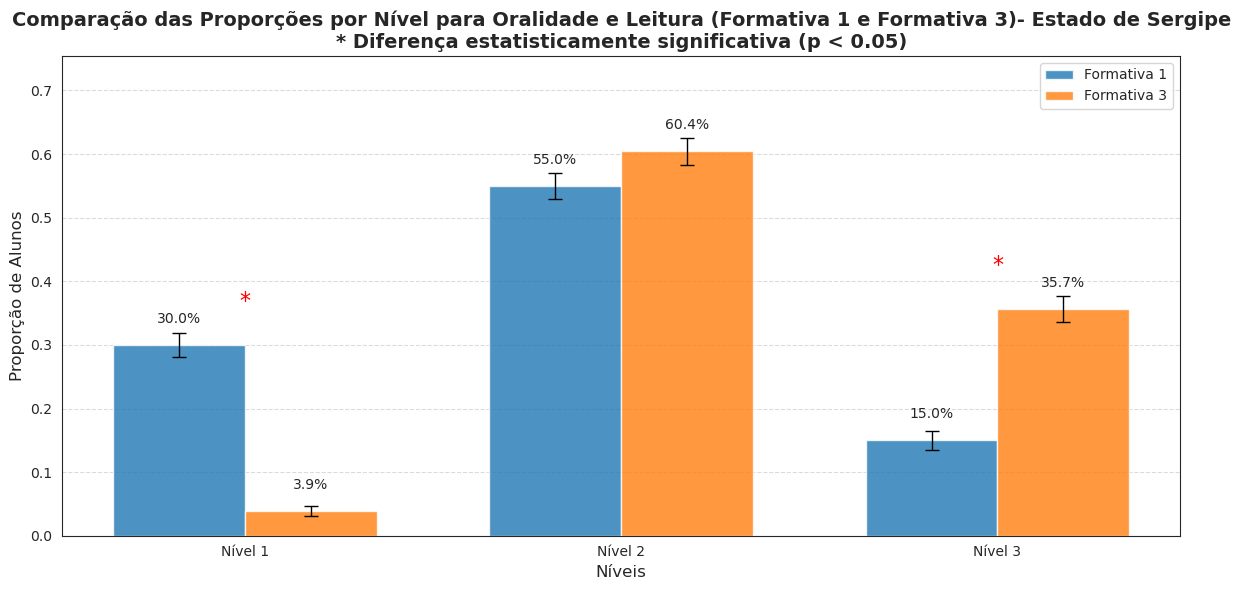

In [24]:
# Aplicando teste de Wilcoxon com função criada
teste_wilcoxon(df_oralidade_leitura_13, 'form_1', 'form_3', output_dir_relatorio_23, 'df_oralidade_leitura_13')
#teste_wilcoxon(df_oralidade_leitura_14, 'form_1', 'form_4', output_dir_relatorio_23, 'df_oralidade_leitura_14')
#teste_wilcoxon(df_oralidade_leitura_15, 'form_1', 'form_somativa', output_dir_relatorio_24, 'df_oralidade_leitura_15')
#teste_wilcoxon(df_oralidade_leitura_34, 'form_3', 'form_4', output_dir_relatorio_24, 'df_oralidade_leitura_34')
#teste_wilcoxon(df_oralidade_leitura_35, 'form_3', 'form_somativa', output_dir_relatorio_24, 'df_oralidade_leitura_35')
#teste_wilcoxon(df_oralidade_leitura_45, 'form_4', 'form_somativa', output_dir_relatorio_24, 'df_oralidade_leitura_45')

In [25]:
# Função para teste de Wilcoxon, criar e salvar gráficos por município
def criar_graficos_municipios(df, form_a, form_b, output_dir, df_name):
    # Agrupar dados por município
    grouped = df.groupby('municipio')
    
    for municipio, group in grouped:
        # Calcular totais para o município
        totais_municipio = {
            f'{form_a}_Nível 1': group[f'{form_a}_Nível 1'].sum(),
            f'{form_a}_Nível 2': group[f'{form_a}_Nível 2'].sum(),
            f'{form_a}_Nível 3': group[f'{form_a}_Nível 3'].sum(),
            f'{form_b}_Nível 1': group[f'{form_b}_Nível 1'].sum(),
            f'{form_b}_Nível 2': group[f'{form_b}_Nível 2'].sum(),
            f'{form_b}_Nível 3': group[f'{form_b}_Nível 3'].sum(),
            f'total_{form_a}': group[f'total_alunos_{form_a}'].sum(),
            f'total_{form_b}': group[f'total_alunos_{form_b}'].sum()
        }
        
        # Calcular proporções
        prop_form_a = [
            totais_municipio[f'{form_a}_Nível 1']/totais_municipio[f'total_{form_a}'],
            totais_municipio[f'{form_a}_Nível 2']/totais_municipio[f'total_{form_a}'],
            totais_municipio[f'{form_a}_Nível 3']/totais_municipio[f'total_{form_a}']
        ]
        
        prop_form_b = [
            totais_municipio[f'{form_b}_Nível 1']/totais_municipio[f'total_{form_b}'],
            totais_municipio[f'{form_b}_Nível 2']/totais_municipio[f'total_{form_b}'],
            totais_municipio[f'{form_b}_Nível 3']/totais_municipio[f'total_{form_b}']
        ]
        
        # Calcular erros padrão
        def calc_erro(p, n):
            return np.sqrt(p * (1 - p) / n) if n > 0 else 0
            
        erro_form_a = [calc_erro(p, totais_municipio[f'total_{form_a}']) for p in prop_form_a]
        erro_form_b = [calc_erro(p, totais_municipio[f'total_{form_b}']) for p in prop_form_b]
        
        # Criar figura
        plt.figure(figsize=(10, 6))
        
        # Configurações do gráfico
        bar_width = 0.35
        index = np.arange(3)
        
        # Tradutor de nomes de práticas de linguagem
        label_praticas = {
            'df_analise_linguistica': 'Análise Linguística',
            'df_oralidade_leitura_13':'Oralidade e Leitura',
            'df_oralidade_leitura_14':'Oralidade e Leitura',
            'df_oralidade_leitura_15':'Oralidade e Leitura',
            'df_oralidade_leitura_34':'Oralidade e Leitura',
            'df_oralidade_leitura_35':'Oralidade e Leitura',
            'df_oralidade_leitura_45':'Oralidade e Leitura',
            'df_producao_escrita_34': 'Produção Escrita',
            'df_producao_escrita_35': 'Produção Escrita',
            'df_producao_escrita_45': 'Produção Escrita'
            }
        
        # Este é o seu "tradutor" de nomes
        label_map = {'form_1': 'Formativa 1',
                     'form_2': 'Formativa 2',
                     'form_3': 'Formativa 3',
                     'form_4': 'Formativa 4',
                     'form_somativa': 'Somativa'
                     }
        
        # Buscando label no dicinário
        label_a = label_map.get(form_a, form_a)
        label_b = label_map.get(form_b, form_b)
        label_pratica_correta = label_praticas.get(df_name, df_name)
        
    
        # Criar barras
        bars1 = plt.bar(index, prop_form_a, bar_width, label=label_a, color='#1f77b4', 
                        yerr=erro_form_a, capsize=5, alpha=0.7)
    
        bars2 = plt.bar(index + bar_width, prop_form_b, bar_width, label=label_b, color='#ff7f0e',
                        yerr=erro_form_b, capsize=5, alpha=0.7)
                
        # Adicionar valores nas barras
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height + 0.03,
                         f'{height:.1%}',
                         ha='center', va='bottom', fontsize=9)
        
        # Verificar significância por nível
        niveis_significativos = []
        for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
            if len(group) >= 3:  # Só testar se tiver turmas suficientes
                stat, p_nivel = wilcoxon(group[f'prop_{form_a}_{nivel}'], 
                                        group[f'prop_{form_b}_{nivel}'])
                if p_nivel < 0.05:
                    niveis_significativos.append(i)
                    y_pos = max(prop_form_a[i], prop_form_b[i]) + 0.05
                    plt.text(index[i] + bar_width/2, y_pos, '*', 
                            ha='center', va='bottom', fontsize=14, color='red')
            
        plt.xlabel('Níveis', fontsize=10)
        plt.ylabel('Proporção de Alunos', fontsize=10)
        plt.title(f'Comparação das Proporções por Nível para {label_pratica_correta} ({label_a} e {label_b}) - {municipio}\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=12)
        plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Ajustar layout e salvar
        plt.tight_layout()
        
        # Criar nome do arquivo (substituir caracteres inválidos)
        filename = f"teste_wilcoxon_{df_name}_{municipio.replace(' ', '_').replace('/', '_')}.png"
        filepath = os.path.join(output_dir, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"Gráfico salvo em: {filepath}")


In [26]:
# Chamar a função para criar os gráficos
criar_graficos_municipios(df_oralidade_leitura_13, 'form_1', 'form_3', output_dir_relatorio_23, 'df_oralidade_leitura_13')
#criar_graficos_municipios(df_oralidade_leitura_14, 'form_1', 'form_4', output_dir_relatorio_23, 'df_oralidade_leitura_14')
#criar_graficos_municipios(df_oralidade_leitura_15, 'form_1', 'form_somativa', output_dir_relatorio_23, 'df_oralidade_leitura_15')
#criar_graficos_municipios(df_oralidade_leitura_34, 'form_3', 'form_4', output_dir_relatorio_23, 'df_oralidade_leitura_34')
#criar_graficos_municipios(df_oralidade_leitura_35, 'form_3', 'form_somativa', output_dir_relatorio_23, 'df_oralidade_leitura_35')
#criar_graficos_municipios(df_oralidade_leitura_45, 'form_4', 'form_somativa', output_dir_relatorio_23, 'df_oralidade_leitura_45')

Gráfico salvo em: Data_files/graficos_relatorio_2.3_turmas_aditivo/extra/teste_wilcoxon_df_oralidade_leitura_13_Aracaju.png
Gráfico salvo em: Data_files/graficos_relatorio_2.3_turmas_aditivo/extra/teste_wilcoxon_df_oralidade_leitura_13_Canindé_de_São_Francisco.png
Gráfico salvo em: Data_files/graficos_relatorio_2.3_turmas_aditivo/extra/teste_wilcoxon_df_oralidade_leitura_13_Capela.png
Gráfico salvo em: Data_files/graficos_relatorio_2.3_turmas_aditivo/extra/teste_wilcoxon_df_oralidade_leitura_13_Carira.png
Gráfico salvo em: Data_files/graficos_relatorio_2.3_turmas_aditivo/extra/teste_wilcoxon_df_oralidade_leitura_13_Itabaiana.png
Gráfico salvo em: Data_files/graficos_relatorio_2.3_turmas_aditivo/extra/teste_wilcoxon_df_oralidade_leitura_13_Itabaianinha.png
Gráfico salvo em: Data_files/graficos_relatorio_2.3_turmas_aditivo/extra/teste_wilcoxon_df_oralidade_leitura_13_Nossa_Senhora_do_Socorro.png
Gráfico salvo em: Data_files/graficos_relatorio_2.3_turmas_aditivo/extra/teste_wilcoxon_df_or

In [27]:
# Criando função para calcular proporções de níveis por município
def calcular_proporcoes_municipios(df, form_X, form_Y):
    df_calc = df.groupby('municipio').agg({
        f'{form_X}_Nível 1': 'sum',
        f'{form_X}_Nível 2': 'sum',
        f'{form_X}_Nível 3': 'sum',
        f'{form_Y}_Nível 1': 'sum',
        f'{form_Y}_Nível 2': 'sum',
        f'{form_Y}_Nível 3': 'sum',
        f'total_alunos_{form_X}': 'sum',
        f'total_alunos_{form_Y}': 'sum'
    }).reset_index()
    
    for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
        df_calc[f'prop_{form_X}_{nivel}'] = 100 * (df_calc[f'{form_X}_{nivel}'] / df_calc[f'total_alunos_{form_X}'])
        df_calc[f'prop_{form_Y}_{nivel}'] = 100 * (df_calc[f'{form_Y}_{nivel}'] / df_calc[f'total_alunos_{form_Y}'])
        
    # Mantendo somente as colunas de proporções
    df_prop = df_calc[['municipio', f'prop_{form_X}_Nível 1', f'prop_{form_X}_Nível 2', f'prop_{form_X}_Nível 3',
                               f'prop_{form_Y}_Nível 1', f'prop_{form_Y}_Nível 2', f'prop_{form_Y}_Nível 3']]
    return df_prop
    
# Calculando proporções por município para Produção Escrita (Formativas 3 e 4) e Oralidade e Leitura (Formativas 1 e 4)
#df_prop_producao_escrita_34 = calcular_proporcoes_municipios(df_producao_escrita_34, 'form_3', 'form_4')
df_prop_oralidade_leitura_13 = calcular_proporcoes_municipios(df_oralidade_leitura_13, 'form_1', 'form_3')
#df_prop_producao_escrita_35 = calcular_proporcoes_municipios(df_producao_escrita_35, 'form_3', 'form_somativa')
#df_prop_oralidade_leitura_15 = calcular_proporcoes_municipios(df_oralidade_leitura_15, 'form_1', 'form_somativa')

# Imprimindo resultados
df_prop_oralidade_leitura_13
#df_prop_producao_escrita_34
#df_prop_oralidade_leitura_15
#df_prop_producao_escrita_35

,municipio,prop_form_1_Nível 1,prop_form_1_Nível 2,prop_form_1_Nível 3,prop_form_3_Nível 1,prop_form_3_Nível 2,prop_form_3_Nível 3
0,Aracaju,16.363636,78.181818,5.454545,7.843137,78.431373,13.725490
1,Canindé de São Francisco,62.068966,37.931034,0.000000,3.773585,47.169811,49.056604
2,Capela,42.307692,53.846154,3.846154,0.000000,36.363636,63.636364
3,Carira,40.000000,15.000000,45.000000,16.666667,44.444444,38.888889
4,Itabaiana,13.333333,74.666667,12.000000,7.812500,76.562500,15.625000
5,Itabaianinha,0.000000,91.666667,8.333333,0.000000,90.909091,9.090909
6,Nossa Senhora do Socorro,8.000000,92.000000,0.000000,0.000000,20.833333,79.166667
7,Porto da Folha,14.634146,53.658537,31.707317,0.000000,47.468354,52.531646
8,Poço Redondo,12.000000,76.000000,12.000000,0.000000,96.000000,4.000000
9,Salgado,57.692308,42.307692,0.000000,8.333333,91.666667,0.000000
